<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 5</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Méthodes bayésiennes</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : probabilités conjointe, marginale et conditionnelle, règle de décision bayésienne, fonction de coût, fonctions discriminantes, inférence bayésienne avec le modèle Beta-Bernoulli, classificateurs naïfs bayésiens gaussien et multinomial, puis réseaux bayésiens. Les exemples reposent sur les jeux de données <i>Titanic</i>, <i>Iris</i>, <i>Wine</i> et <i>SMS Spam Collection</i>. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `seaborn` (≥ 0.13), `scipy` et `scikit-learn` (≥ 1.8).  
**Données externes** : le fichier `./data/sms.tsv` doit être téléchargé et placé manuellement dans le sous-dossier `data`. Le jeu de données `titanic` est chargé avec `seaborn` ; une connexion Internet peut être nécessaire lors de son premier chargement.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'seaborn', 'scipy', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
seaborn            0.13.2
scipy              1.18.0
scikit-learn       1.9.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.1 : Probabilités conjointe, marginale et conditionnelle sur le jeu de données Titanic</h3>

In [3]:
import seaborn as sns
import pandas as pd

# Chargement du jeu de données Titanic
titanic = sns.load_dataset('titanic')
m = len(titanic)

# Distribution conjointe p(survie, classe)
conjointe = pd.crosstab(titanic['survived'], titanic['pclass']) / m
conjointe.index = ['survie=0', 'survie=1']
conjointe.columns = ['classe=1', 'classe=2', 'classe=3']

# Distributions marginales
marg_survie = titanic['survived'].value_counts(normalize=True).sort_index()
marg_classe = titanic['pclass'].value_counts(normalize=True).sort_index()

# Probabilités conditionnelles p(survie | classe)
conditionnelle = pd.crosstab(titanic['pclass'], titanic['survived'], normalize='index')
conditionnelle.index = ['classe=1', 'classe=2', 'classe=3']
conditionnelle.columns = ['survie=0', 'survie=1']

# Affichage
display(titanic.head(5))
print()

L = 55
print("=" * L)
print("Distribution conjointe p(survie, classe)")
print("=" * L)
print(conjointe.to_string(float_format=lambda x: f"{x:.4f}"))
print()
print("-" * L)
print("Distributions marginales")
print("-" * L)
print(f"{'p(survie=0)':<14}{marg_survie[0]:.4f}\t{'p(survie=1)':<14}{marg_survie[1]:.4f}")
print(f"{'p(classe=1)':<14}{marg_classe[1]:.4f}\t{'p(classe=2)':<14}{marg_classe[2]:.4f}\t{'p(classe=3)':<14}{marg_classe[3]:.4f}")
print()
print("-" * L)
print("Probabilités conditionnelles p(survie | classe)")
print("-" * L)
print(conditionnelle.to_string(float_format=lambda x: f"{x:.4f}"))
print("=" * L)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Distribution conjointe p(survie, classe)
          classe=1  classe=2  classe=3
survie=0    0.0898    0.1089    0.4175
survie=1    0.1526    0.0976    0.1336

-------------------------------------------------------
Distributions marginales
-------------------------------------------------------
p(survie=0)   0.6162	p(survie=1)   0.3838
p(classe=1)   0.2424	p(classe=2)   0.2065	p(classe=3)   0.5511

-------------------------------------------------------
Probabilités conditionnelles p(survie | classe)
-------------------------------------------------------
          survie=0  survie=1
classe=1    0.3704    0.6296
classe=2    0.5272    0.4728
classe=3    0.7576    0.2424


<h3><span style="font-size: 30px">&#127924;</span> Figure : Distribution conjointe et vraisemblance (Titanic)</h3>

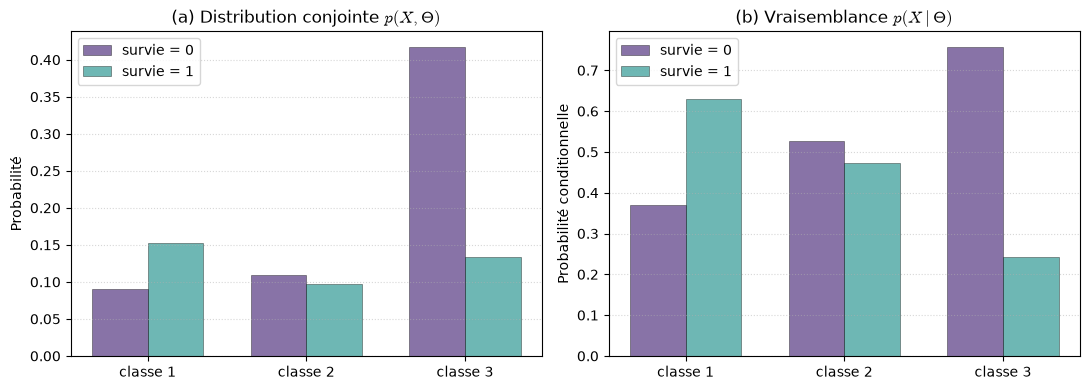

In [4]:
import numpy as np

classes = [1, 2, 3]
conj_0 = [len(titanic[(titanic['survived'] == 0) &
                      (titanic['pclass'] == c)]) / m for c in classes]
conj_1 = [len(titanic[(titanic['survived'] == 1) &
                      (titanic['pclass'] == c)]) / m for c in classes]
cond_0 = [len(titanic[(titanic['survived'] == 0) & (titanic['pclass'] == c)])
          / len(titanic[titanic['pclass'] == c]) for c in classes]
cond_1 = [len(titanic[(titanic['survived'] == 1) & (titanic['pclass'] == c)])
          / len(titanic[titanic['pclass'] == c]) for c in classes]

larg = 0.35
pos = np.arange(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (a) Distribution conjointe
axes[0].bar(pos - larg/2, conj_0, larg, color=VIOLET,
            label='survie = 0', edgecolor='black', linewidth=0.4, alpha=0.65)
axes[0].bar(pos + larg/2, conj_1, larg, color=SARCELLE,
            label='survie = 1', edgecolor='black', linewidth=0.4, alpha=0.65)
axes[0].set_title('(a) Distribution conjointe $p(X, \\Theta)$')
axes[0].set_ylabel('Probabilité')

# (b) Vraisemblance
axes[1].bar(pos - larg/2, cond_0, larg, color=VIOLET,
            label='survie = 0', edgecolor='black', linewidth=0.4, alpha=0.65)
axes[1].bar(pos + larg/2, cond_1, larg, color=SARCELLE,
            label='survie = 1', edgecolor='black', linewidth=0.4, alpha=0.65)
axes[1].set_title('(b) Vraisemblance $p(X \\mid \\Theta)$')
axes[1].set_ylabel('Probabilité conditionnelle')

for ax in axes:
    ax.set_xticks(pos)
    ax.set_xticklabels(['classe 1', 'classe 2', 'classe 3'])
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax.legend()

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-ProbConjointe-Titanic")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.2 : Règle de décision bayésienne sur le jeu de données Iris : estimation des vraisemblances gaussiennes et localisation de la frontière de décision</h3>

In [5]:
import numpy as np
from scipy.stats import norm
from sklearn.datasets import load_iris

# Chargement : setosa (0) et versicolor (1), longueur du sépale
iris   = load_iris()
masque = iris.target < 2
x_obs  = iris.data[masque, 0]
y_obs  = iris.target[masque]

# Probabilités a priori estimées par les fréquences
P_w1 = (y_obs == 0).mean()
P_w2 = (y_obs == 1).mean()

# Vraisemblances gaussiennes estimées par maximum de vraisemblance
mu1, sigma1 = norm.fit(x_obs[y_obs == 0])
mu2, sigma2 = norm.fit(x_obs[y_obs == 1])

# Frontière de décision : p(x|w1) P(w1) = p(x|w2) P(w2)
grille = np.linspace(4.0, 7.5, 2000)
diff = (norm.pdf(grille, mu1, sigma1) * P_w1 - norm.pdf(grille, mu2, sigma2) * P_w2)
zone     = (grille > mu1) & (grille < mu2)
x_etoile = grille[zone][np.argmin(np.abs(diff[zone]))]

# Classification par la règle de Bayes
pred = np.where(norm.pdf(x_obs, mu1, sigma1) * P_w1
                > norm.pdf(x_obs, mu2, sigma2) * P_w2, 0, 1)
exactitude = (pred == y_obs).mean()

# Affichage
SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
L = 50

print("=" * L)
print("Classification bayésienne (Setosa vs Versicolor)")
print("=" * L)
print(f"{'Paramètre':<22}{'Valeur'}")
print("-" * L)
print(f"{'P(ω' + '1'.translate(SUP) + ')':<22}{P_w1:.2f}")
print(f"{'P(ω' + '2'.translate(SUP) + ')':<22}{P_w2:.2f}")
print(f"{'μ' + '1'.translate(SUP) + ' (Setosa)':<22}{mu1:.2f} cm")
print(f"{'σ' + '1'.translate(SUP) + ' (Setosa)':<22}{sigma1:.2f} cm")
print(f"{'μ' + '2'.translate(SUP) + ' (Versicolor)':<22}{mu2:.2f} cm")
print(f"{'σ' + '2'.translate(SUP) + ' (Versicolor)':<22}{sigma2:.2f} cm")
print("-" * L)
print(f"{'x* (frontière)':<22}{x_etoile:.2f} cm")
print(f"{'Exactitude':<22}{exactitude:.2f}")
print("=" * L)

Classification bayésienne (Setosa vs Versicolor)
Paramètre             Valeur
--------------------------------------------------
P(ω₁)                 0.50
P(ω₂)                 0.50
μ₁ (Setosa)           5.01 cm
σ₁ (Setosa)           0.35 cm
μ₂ (Versicolor)       5.94 cm
σ₂ (Versicolor)       0.51 cm
--------------------------------------------------
x* (frontière)        5.45 cm
Exactitude            0.89


<h3><span style="font-size: 30px">&#127924;</span> Figure : Vraisemblances, régions de décision et probabilités a posteriori (Iris)</h3>

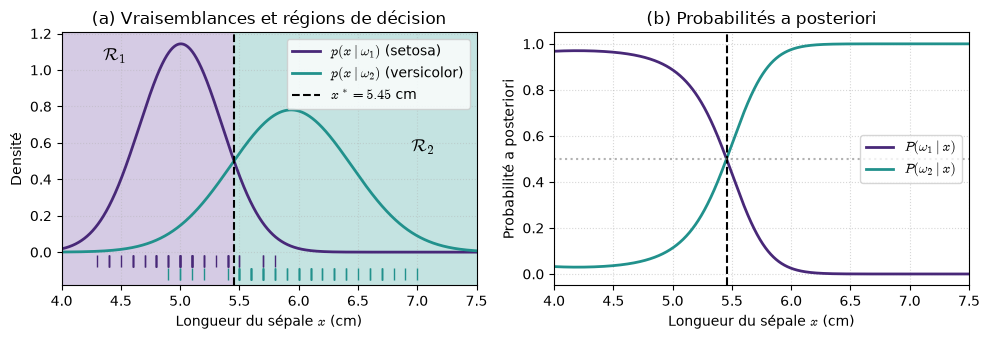

In [6]:
# Probabilités a posteriori par le théorème de Bayes
p_x = (norm.pdf(grille, mu1, sigma1) * P_w1
       + norm.pdf(grille, mu2, sigma2) * P_w2)
post1 = norm.pdf(grille, mu1, sigma1) * P_w1 / p_x
post2 = norm.pdf(grille, mu2, sigma2) * P_w2 / p_x

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# (a) Vraisemblances et régions de décision
ax = axes[0]
ax.axvspan(4.0, x_etoile, color=ZONE[VIOLET])
ax.axvspan(x_etoile, 7.5, color=ZONE[SARCELLE])
ax.plot(grille, norm.pdf(grille, mu1, sigma1), color=VIOLET, linewidth=2,
        label='$p(x \\mid \\omega_1)$ (setosa)')
ax.plot(grille, norm.pdf(grille, mu2, sigma2), color=SARCELLE, linewidth=2,
        label='$p(x \\mid \\omega_2)$ (versicolor)')
ax.plot(x_obs[y_obs == 0], np.full((y_obs == 0).sum(), -0.05), '|',
        color=VIOLET, markersize=8)
ax.plot(x_obs[y_obs == 1], np.full((y_obs == 1).sum(), -0.12), '|',
        color=SARCELLE, markersize=8)
ax.axvline(x_etoile, color='black', linestyle='--', linewidth=1.5,
           label=f'$x^* = {x_etoile:.2f}$ cm')
ax.text(4.35, 1.05, '$\\mathcal{R}_1$', fontsize=13)
ax.text(6.95, 0.55, '$\\mathcal{R}_2$', fontsize=13)
ax.set_xlabel('Longueur du sépale $x$ (cm)')
ax.set_ylabel('Densité')
ax.set_xlim(4.0, 7.5)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)
ax.set_title('(a) Vraisemblances et régions de décision')

# (b) Probabilités a posteriori
ax = axes[1]
ax.plot(grille, post1, color=VIOLET, linewidth=2,
        label='$P(\\omega_1 \\mid x)$')
ax.plot(grille, post2, color=SARCELLE, linewidth=2,
        label='$P(\\omega_2 \\mid x)$')
ax.axvline(x_etoile, color='black', linestyle='--', linewidth=1.5)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.6)
ax.set_xlabel('Longueur du sépale $x$ (cm)')
ax.set_ylabel('Probabilité a posteriori')
ax.set_xlim(4.0, 7.5)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_title('(b) Probabilités a posteriori')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-RegleDecision-Iris")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.3 : Impact de la matrice de coût sur le seuil de décision pour la détection de pourriels (SMS Spam Collection)</h3>

### Jeu de données SMS Spam Collection

Le jeu de données **SMS Spam Collection** contient un ensemble de messages SMS
étiquetés comme légitimes (*ham*) ou indésirables (*spam*). Il est disponible
à l'adresse suivante :

[SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection)

Pour exécuter les exemples de ce chapitre, placez le fichier `sms.tsv` dans
le dossier `./data/`.

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix

# Chargement du jeu de données SMS Spam Collection
sms = pd.read_csv('./data/sms.tsv', sep='\t', header=None, names=['etiquette', 'message'])

sms['y'] = (sms['etiquette'] == 'spam').astype(int)
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    sms['message'], sms['y'], test_size=0.3, stratify=sms['y'], random_state=42)

# Vectorisation des textes et classificateur multinomial
vectoriseur = CountVectorizer()
X_train = vectoriseur.fit_transform(X_train_txt)
X_test  = vectoriseur.transform(X_test_txt)
mnb = MultinomialNB(alpha=1.0).fit(X_train, y_train)

# Probabilités a posteriori P(spam | x) sur l'ensemble de test
p_spam = mnb.predict_proba(X_test)[:, 1]

SUP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")
L = 55

# Deux matrices de coût : symétrique et asymétrique
print("=" * L)
print("Effet de la matrice de coût sur le seuil de décision")
print("=" * L)
print(f"{'λ' + '12'.translate(SUP):<8}{'λ' + '21'.translate(SUP):<8}{'Seuil':<10}{'FP':<8}{'FN'}")
print("-" * L)
for l12, l21 in [(1, 1), (10, 1)]:
    seuil = l12 / (l12 + l21)
    y_pred = (p_spam > seuil).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    print(f"{l12:<8}{l21:<8}{seuil:<10.2f}{cm[0, 1]:<8}{cm[1, 0]}")
print("=" * L)

Effet de la matrice de coût sur le seuil de décision
λ₁₂     λ₂₁     Seuil     FP      FN
-------------------------------------------------------
1       1       0.50      4       19
10      1       0.91      2       29


<h3><span style="font-size: 30px">&#127924;</span> Figure : Probabilités a posteriori et seuils de décision (SMS Spam Collection)</h3>

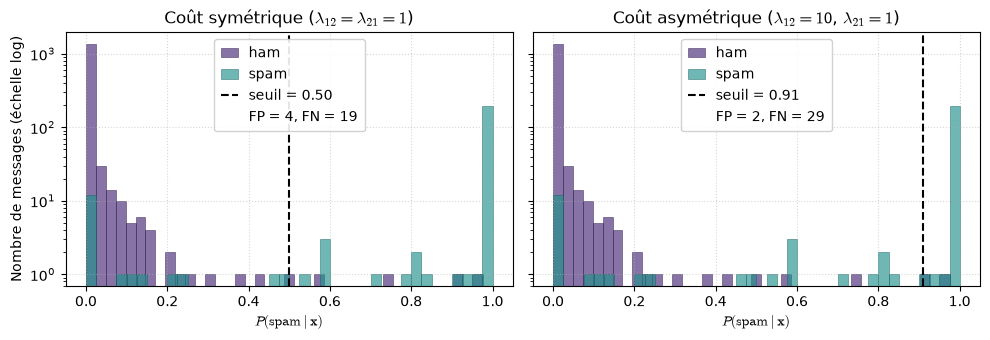

In [8]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

couts = [
    {'l12': 1, 'l21': 1,
     'titre': 'Coût symétrique ($\\lambda_{12}=\\lambda_{21}=1$)'},
    {'l12': 10, 'l21': 1,
     'titre': 'Coût asymétrique ($\\lambda_{12}=10$, $\\lambda_{21}=1$)'},
]

for ax, c in zip(axes, couts):
    l12, l21 = c['l12'], c['l21']
    seuil = l12 / (l12 + l21)
    y_pred_c = (p_spam > seuil).astype(int)
    cm_c = confusion_matrix(y_test, y_pred_c)
    fp, fn = cm_c[0, 1], cm_c[1, 0]

    ax.hist(p_spam[y_test == 0], bins=40, color=VIOLET, alpha=0.65,
            edgecolor=BORD[VIOLET], linewidth=0.5, label='ham', log=True)
    ax.hist(p_spam[y_test == 1], bins=40, color=SARCELLE, alpha=0.65,
            edgecolor=BORD[SARCELLE], linewidth=0.5, label='spam', log=True)
    ax.axvline(seuil, color='black', linestyle='--', linewidth=1.5,
               label=f'seuil = {seuil:.2f}')

    poignees, etiquettes = ax.get_legend_handles_labels()
    poignees.append(Line2D([], [], color='none'))
    etiquettes.append(f'FP = {fp}, FN = {fn}')
    ax.legend(poignees, etiquettes, loc='upper center',
              framealpha=0.9, handlelength=1.2, borderpad=0.5)

    ax.set_title(c['titre'])
    ax.set_xlabel('$P(\\mathrm{spam} \\mid \\mathbf{x})$')
    ax.grid(True, linestyle=':', alpha=0.5)

axes[0].set_ylabel('Nombre de messages (échelle log)')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-FonctionCout")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.4 : Fonctions discriminantes et régions de décision pour la classification par la taille</h3>

In [9]:
import numpy as np
from scipy.stats import norm

# Paramètres du modèle : femmes (F) et hommes (H)
mu_F, sigma_F = 1.65, 0.16
mu_H, sigma_H = 1.75, 0.15
P_F, P_H      = 0.5, 0.5
t_vals        = np.linspace(1.2, 2.2, 500)

# Fonctions discriminantes logarithmiques
g1 = np.log(norm.pdf(t_vals, mu_F, sigma_F)) + np.log(P_F)
g2 = np.log(norm.pdf(t_vals, mu_H, sigma_H)) + np.log(P_H)
g  = g1 - g2

# Frontière de décision entre les deux moyennes : g(t) = 0
zone      = (t_vals > mu_F) & (t_vals < mu_H)
frontiere = t_vals[zone][np.argmin(np.abs(g[zone]))]
print(f"Frontiere de decision : t* = {frontiere:.2f} m")

Frontiere de decision : t* = 1.69 m


<h3><span style="font-size: 30px">&#127924;</span> Figure : Fonctions discriminantes et régions de décision (classification par la taille)</h3>

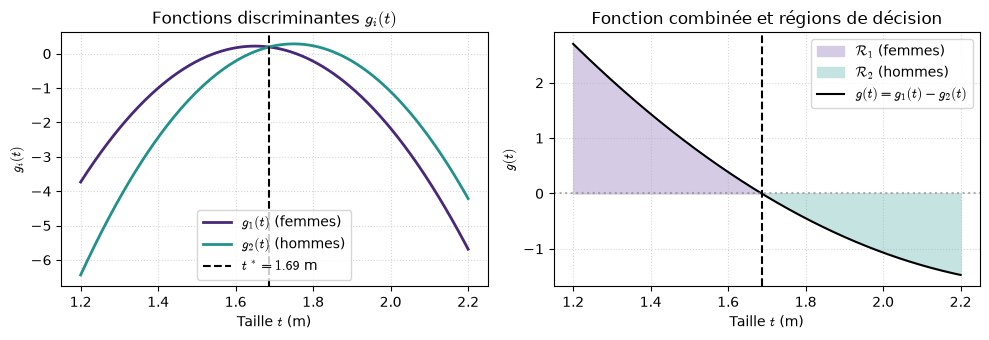

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.plot(t_vals, g1, color=VIOLET, linewidth=2, label='$g_1(t)$ (femmes)')
ax.plot(t_vals, g2, color=SARCELLE, linewidth=2, label='$g_2(t)$ (hommes)')
ax.axvline(frontiere, color='black', linestyle='--', linewidth=1.5,
           label=f'$t^* = {frontiere:.2f}$ m')
ax.set_title('Fonctions discriminantes $g_i(t)$')
ax.set_xlabel('Taille $t$ (m)')
ax.set_ylabel('$g_i(t)$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[1]
ax.fill_between(t_vals, g, 0, where=(g > 0), color=ZONE[VIOLET],
                label='$\\mathcal{R}_1$ (femmes)')
ax.fill_between(t_vals, g, 0, where=(g < 0), color=ZONE[SARCELLE],
                label='$\\mathcal{R}_2$ (hommes)')
ax.plot(t_vals, g, color='black', linewidth=1.5,
        label='$g(t) = g_1(t) - g_2(t)$')
ax.axvline(frontiere, color='black', linestyle='--', linewidth=1.5)
ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax.set_title('Fonction combinée et régions de décision')
ax.set_xlabel('Taille $t$ (m)')
ax.set_ylabel('$g(t)$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.5)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-FoncDiscriminante-Tailles")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.5 : Fonctions discriminantes du classificateur bayésien gaussien sur le jeu de données Wine, dans l'espace des deux premières composantes principales</h3>

In [11]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Chargement, standardisation et projection ACP
wine  = load_wine()
X_std = StandardScaler().fit_transform(wine.data)
X_pca = PCA(n_components=2).fit_transform(X_std)

# Classificateur bayésien gaussien dans le plan CP1-CP2
gnb_wine = GaussianNB().fit(X_pca, wine.target)

# Évaluation des fonctions discriminantes g_i sur une grille
xx, yy = np.meshgrid(
    np.linspace(X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1, 300),
    np.linspace(X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1, 300))
log_proba = gnb_wine.predict_log_proba(np.c_[xx.ravel(), yy.ravel()])
# log_proba[:, i] contient g_i(x) = ln P(omega_i | x)

<h3><span style="font-size: 30px">&#127924;</span> Figure : Les trois fonctions discriminantes (Wine)</h3>

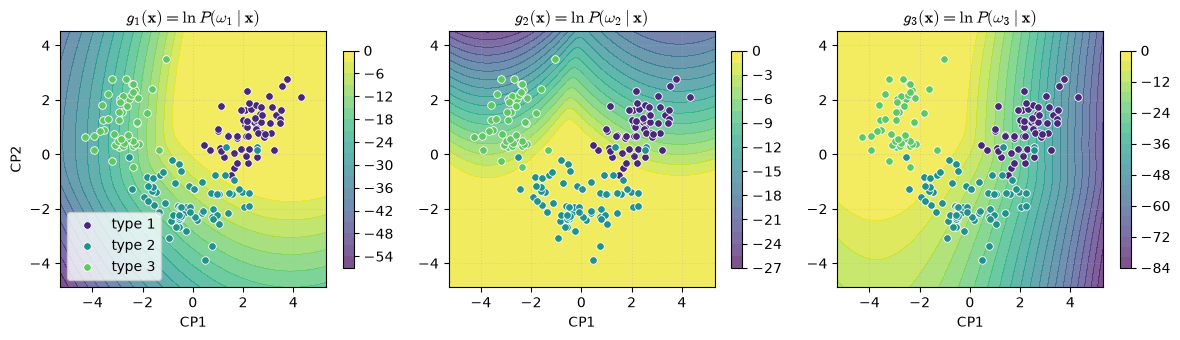

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

couleurs = [VIOLET, SARCELLE, VERT]

for i, ax in enumerate(axes):
    g_i = log_proba[:, i].reshape(xx.shape)
    cf = ax.contourf(xx, yy, g_i, levels=20, cmap='viridis', alpha=0.7)
    fig.colorbar(cf, ax=ax, shrink=0.85)

    for cls, coul in enumerate(couleurs):
        idx = wine.target == cls
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1], color=coul,
                   edgecolors='white', linewidths=0.6, s=30,
                   label=f'type {cls + 1}')

    ax.set_title(f'$g_{i+1}(\\mathbf{{x}}) = '
                 f'\\ln P(\\omega_{i+1} \\mid \\mathbf{{x}})$')
    ax.set_xlabel('CP1')
    ax.grid(True, linestyle=':', alpha=0.35)
    if i == 0:
        ax.set_ylabel('CP2')
        ax.legend(loc='lower left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-FoncDiscriminantes-Wine")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.6 : Mise à jour bayésienne du taux de pourriels avec le modèle Beta-Bernoulli, et comparaison des estimateurs MLE, MAP et MMSE</h3>

In [13]:
# Le jeu de données sms provient du listing de la
# section fonction de coût

# A priori Beta(2, 8) : environ un message sur cinq serait
# un pourriel (dix messages imaginaires dont deux pourriels)
a, b = 2, 8
tailles = [10, 100, 1000, len(sms)]

resultats = []
for m_obs in tailles:
    s = sms['y'].iloc[:m_obs].sum()
    # Loi a posteriori : Beta(a + s, b + m - s)
    mle = s / m_obs
    map_ = (a + s - 1) / (a + b + m_obs - 2)
    mmse = (a + s) / (a + b + m_obs)
    resultats.append((m_obs, s, mle, map_, mmse))

# --- Affichage ---
L = 45
print("=" * L)
print("Estimation de P(spam) : MLE, MAP, MMSE")
print("=" * L)
print(f"{'m':<8}{'s':<8}{'MLE':<10}{'MAP':<10}{'MMSE'}")
print("-" * L)

for m_obs, s, mle, map_, mmse in resultats:
    print(f"{m_obs:<8}{s:<8}"
          f"{mle:<10.3f}{map_:<10.3f}{mmse:.3f}")

print("=" * L)

Estimation de P(spam) : MLE, MAP, MMSE
m       s       MLE       MAP       MMSE
---------------------------------------------
10      4       0.400     0.278     0.300
100     17      0.170     0.167     0.173
1000    152     0.152     0.152     0.152
5572    747     0.134     0.134     0.134


<h3><span style="font-size: 30px">&#127924;</span> Figure : Mise à jour bayésienne de la loi a posteriori (Beta-Bernoulli)</h3>

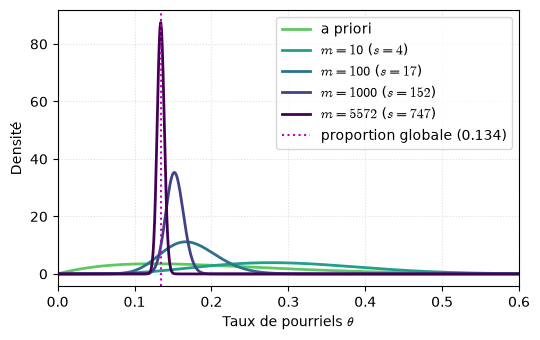

In [14]:
from scipy.stats import beta

theta_grid = np.linspace(0, 1, 1000)
tailles = [0, 10, 100, 1000, 5572]

fig, ax = plt.subplots(figsize=(5.5, 3.5))

for i, m_obs in enumerate(tailles):
    s = int(sms['y'].iloc[:m_obs].sum())
    dens = beta.pdf(theta_grid, a + s, b + m_obs - s)
    etiq = 'a priori' if m_obs == 0 else f'$m = {m_obs}$ ($s = {s}$)'
    ax.plot(theta_grid, dens,
            color=plt.cm.viridis(0.75 - 0.75 * i / (len(tailles) - 1)),
            linewidth=2, label=etiq)

ax.axvline(sms['y'].mean(), color=MAGENTA, linestyle=':', linewidth=1.5,
           label=f"proportion globale ({sms['y'].mean():.3f})")

ax.set_xlim(0, 0.6)
ax.set_xlabel('Taux de pourriels $\\theta$')
ax.set_ylabel('Densité')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-BetaBernoulli")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.7 : Classificateur naïf bayésien gaussien sur le jeu de données Iris</h3>

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Partition du jeu Iris : 70 % entraînement, 30 % test
X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(
    iris.data, iris.target, test_size=0.3,
    stratify=iris.target, random_state=42)

# Standardisation ajustée uniquement sur les données d'entraînement
scaler = StandardScaler()
X_tr_std = scaler.fit_transform(X_tr_ir)
X_te_std = scaler.transform(X_te_ir)

# ACP ajustée uniquement sur les données d'entraînement
pca = PCA(n_components=2)
X_tr_pca = pca.fit_transform(X_tr_std)
X_te_pca = pca.transform(X_te_std)

# Classificateur naïf bayésien gaussien dans l'espace ACP
gnb = GaussianNB()
gnb.fit(X_tr_pca, y_tr_ir)
y_pred = gnb.predict(X_te_pca)

# Afficher le rapport de classification
print(classification_report(y_te_ir, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.74      0.93      0.82        15
   virginica       0.91      0.67      0.77        15

    accuracy                           0.87        45
   macro avg       0.88      0.87      0.86        45
weighted avg       0.88      0.87      0.86        45



<h3><span style="font-size: 30px">&#127924;</span>Figure : Régions et frontières de décision du classificateur naïf bayésien gaussien (Iris, espace ACP)</h3>

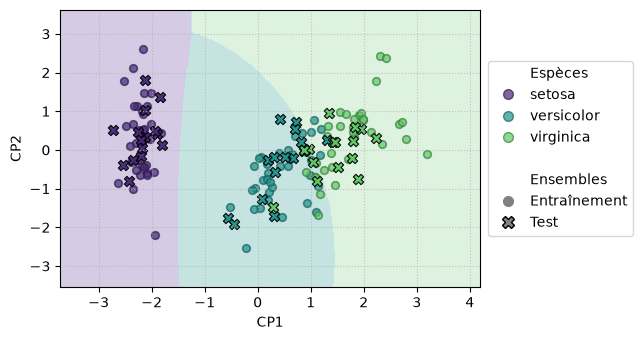

In [16]:
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

# Couleurs des espèces et zones pâles (conventions du livre)
couleurs_especes = [VIOLET, SARCELLE, VERT]
zones = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE], ZONE[VERT]])

# Limites de la figure incluant les ensembles d'entraînement et de test
X_pca_all = np.vstack((X_tr_pca, X_te_pca))

xx, yy = np.meshgrid(np.linspace(X_pca_all[:, 0].min() - 1,
                                 X_pca_all[:, 0].max() + 1, 400),
                     np.linspace(X_pca_all[:, 1].min() - 1,
                                 X_pca_all[:, 1].max() + 1, 400))

# Régions de décision du modèle entraîné
Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Tracé de la figure
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=zones)

# Observations de l'ensemble d'entraînement
for cls, coul in enumerate(couleurs_especes):
    idx = y_tr_ir == cls
    ax.scatter(X_tr_pca[idx, 0], X_tr_pca[idx, 1],
               color=coul, edgecolors=BORD[coul], linewidths=1.2,
               s=30, alpha=0.70)

# Observations de l'ensemble de test
for cls, coul in enumerate(couleurs_especes):
    idx = y_te_ir == cls
    ax.scatter(X_te_pca[idx, 0], X_te_pca[idx, 1],
               color=coul, edgecolors='black', marker='X',
               linewidths=0.8, s=55, alpha=0.95)

ax.set_xlabel('CP1')
ax.set_ylabel('CP2')
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()   # AVANT la légende

# Légende unique, avec deux sections titrées
vide = Line2D([], [], linestyle='None')

entrees = [vide]
for cls, coul in enumerate(couleurs_especes):
    entrees.append(Line2D([0], [0], marker='o', linestyle='None',
                          markerfacecolor=coul, markeredgecolor=BORD[coul],
                          markersize=7, alpha=0.70))
entrees += [vide, vide]
entrees.append(Line2D([0], [0], marker='o', linestyle='None',
                      markerfacecolor='gray', markeredgecolor='gray',
                      markersize=7))
entrees.append(Line2D([0], [0], marker='X', linestyle='None',
                      markerfacecolor='gray', markeredgecolor='black',
                      markersize=8))

etiquettes = ['Espèces'] + list(iris.target_names) + ['', 'Ensembles', 'Entraînement', 'Test']

ax.legend(entrees, etiquettes, loc='center left',
          bbox_to_anchor=(1.02, 0.5), borderaxespad=0.,
          handletextpad=0.6, labelspacing=0.5)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap5-FrontiereNaiveBayes")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.8 : Classificateur naïf bayésien multinomial sur le jeu de données SMS Spam Collection : évaluation et mots les plus discriminants</h3>

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score

# Le vectoriseur, le classificateur mnb et la partition
# proviennent du listing de la section fonction de coût
m = len(sms)
taille_vocab = X_train.shape[1]
y_pred = mnb.predict(X_test)
exactitude = accuracy_score(y_test, y_pred)

# Rapport de log-probabilités pour chaque mot
# y = 1 : spam ; y = 0 : ham
log_ratio = mnb.feature_log_prob_[1] - mnb.feature_log_prob_[0]
vocab = np.array(vectoriseur.get_feature_names_out())
idx = np.argsort(log_ratio)

# Nombre de mots affichés pour chaque classe
n_mots = 8
mots_spam = ', '.join(vocab[idx[-n_mots:]][::-1])
mots_ham  = ', '.join(vocab[idx[:n_mots]])

# Affichage des résultats
L = 73
print("=" * L)
print("Classificateur naïf bayésien multinomial (SMS Spam)")
print("=" * L)
print(f"{'Messages (m)':<24}{m}")
print(f"{'Taille du vocabulaire':<24}{taille_vocab}")
print(f"{'Exactitude (test)':<24}{exactitude:.4f}")
print("-" * L)
print(f"{'Mots typiques (spam)':<24}{mots_spam}")
print(f"{'Mots typiques (ham)':<24}{mots_ham}")
print("=" * L)

Classificateur naïf bayésien multinomial (SMS Spam)
Messages (m)            5572
Taille du vocabulaire   7120
Exactitude (test)       0.9862
-------------------------------------------------------------------------
Mots typiques (spam)    claim, prize, 150p, tone, 500, 18, cs, guaranteed
Mots typiques (ham)     gt, lt, he, lor, da, she, later, wat


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 5.9 : Construction et inférence dans un réseau bayésien - implémentation manuelle</h3>

In [18]:
import numpy as np

# Tables de probabilités conditionnelles (CPT)
P_Rain = np.array([0.8, 0.2])

P_Sprinkler_given_Rain = np.array([
    [0.60, 0.99],
    [0.40, 0.01]
])

P_WetGrass_given_SR = np.array([
    [[1.00, 0.10], [0.10, 0.01]],
    [[0.00, 0.90], [0.90, 0.99]]
])

def inferer_rain_sachant_wetgrass(wg):
    p = np.zeros(2)
    for r in range(2):
        for s in range(2):
            p[r] += (P_Rain[r]
                     * P_Sprinkler_given_Rain[s, r]
                     * P_WetGrass_given_SR[wg, s, r])
    return p / p.sum()

def inferer_rain_sachant_wetgrass_sprinkler(wg, s_obs):
    p = np.zeros(2)
    for r in range(2):
        p[r] = (P_Rain[r]
                * P_Sprinkler_given_Rain[s_obs, r]
                * P_WetGrass_given_SR[wg, s_obs, r])
    return p / p.sum()

def inferer_sprinkler_sachant_wetgrass(wg):
    p = np.zeros(2)
    for s in range(2):
        for r in range(2):
            p[s] += (P_Rain[r]
                     * P_Sprinkler_given_Rain[s, r]
                     * P_WetGrass_given_SR[wg, s, r])
    return p / p.sum()

p1 = inferer_rain_sachant_wetgrass(wg=1)
p2 = inferer_rain_sachant_wetgrass_sprinkler(wg=1, s_obs=0)
p3 = inferer_sprinkler_sachant_wetgrass(wg=1)
p4 = inferer_rain_sachant_wetgrass_sprinkler(wg=1, s_obs=1)

requetes = [
    ('P(Rain=1 | WetGrass=1)', p1[1]),
    ('P(Rain=1 | WetGrass=1, Sprinkler=0)', p2[1]),
    ('P(Sprinkler=1 | WetGrass=1)', p3[1]),
    ('P(Rain=1 | WetGrass=1, Sprinkler=1)', p4[1]),
]

print("=" * 48)
print("Inférence dans le réseau bayésien")
print("=" * 48)
print(f"{'Requête':<37}Probabilité")
print("-" * 48)
print(f"{'P(Rain=1 | WetGrass=1)':<37}{p1[1]:.4f}")
print(f"{'P(Rain=1 | WetGrass=1, Sprinkler=0)':<37}{p2[1]:.4f}")
print(f"{'P(Sprinkler=1 | WetGrass=1)':<37}{p3[1]:.4f}")
print(f"{'P(Rain=1 | WetGrass=1, Sprinkler=1)':<37}{p4[1]:.4f}")
print("=" * 48)

Inférence dans le réseau bayésien
Requête                              Probabilité
------------------------------------------------
P(Rain=1 | WetGrass=1)               0.3849
P(Rain=1 | WetGrass=1, Sprinkler=0)  1.0000
P(Sprinkler=1 | WetGrass=1)          0.6194
P(Rain=1 | WetGrass=1, Sprinkler=1)  0.0068


<hr style='border-top:4px solid #1F77B4;'>